In [1]:
import pandas as pd

### Load single-cell data

In [2]:
%%time
df = pd.read_pickle('/Users/dayn/data/macrohet_mac/verified_df.pkl')


CPU times: user 682 ms, sys: 336 ms, total: 1.02 s
Wall time: 1.21 s


In [3]:
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.0,85.30408,914.186190,980.270593,0.0,0.0,1.0,716.326599,843.3125,...,NaN,0.0,0.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,0,7.0
1,0.5,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,0.5,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,1,7.0
2,1.0,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,1.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,2,7.0
3,1.5,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,1.5,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,3,7.0
4,2.0,NaN,85.30408,NaN,980.270593,NaN,0.0,1.0,716.326599,843.3125,...,NaN,0.0,2.0,0.0,NaN,"[1.92, 61.44]",[13.0],0.999188,4,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007856,59.5,0.0,NaN,261.387613,NaN,False,0.0,0.0,1034.000000,1161.0000,...,NaN,0.0,58.5,0.0,None,None,None,-1.02,119,NaN
2007857,60.0,0.0,NaN,275.109568,NaN,False,0.0,0.0,972.000000,1147.0000,...,NaN,0.0,59.0,0.0,None,None,None,-1.02,120,NaN
2007858,60.5,0.0,NaN,404.484815,NaN,False,0.0,0.0,948.000000,1159.0000,...,NaN,0.0,59.5,0.0,None,None,None,-1.02,121,NaN
2007859,61.0,0.0,NaN,297.055758,NaN,NaN,0.0,0.0,874.000000,1163.0000,...,NaN,0.0,NaN,NaN,None,None,None,-1.02,122,NaN


### Plotting all intial doubling times regardless of origin

/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_6495/108664730.py:79: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_6495/108664730.py:79: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_6495/108664730.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin.set_yticklabels(order, fontweight='bold', fontsize=12)
/var/folders/8x/6gc_8nk523n3ry7gdlxbfzgs3msxj9/T/ipykernel_6495/108664730.py:193: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_resu

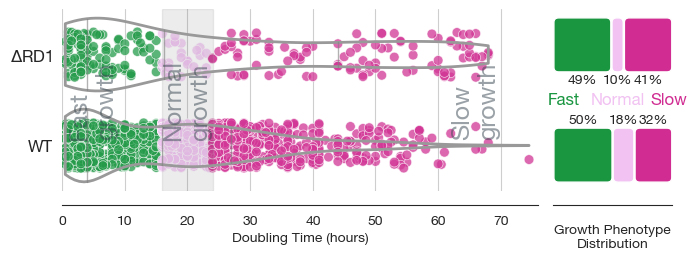

In [96]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# --- Global Style & Font Settings ---
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
sns.set_style("white")

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica Neue']
plt.rcParams['pdf.fonttype'] = 42 

# --- Contextual Definitions ---
growth_colors = {
    "Fast": '#1a9641',   # Deep Green
    "Normal": '#F1C2F2', # Light Pink/Purple
    "Slow": '#D02C91'    # Deep Magenta
}
growth_order = ["Fast", "Normal", "Slow"]

# --- Dimensions ---
width_mm = 200
height_mm = 60
width_in = width_mm / 25.4
height_in = height_mm / 25.4

# --- Data Loading & Clean ---
subset_df = df.explode("Doubling Times", ignore_index=True)
subset_df["Doubling Times"] = pd.to_numeric(subset_df["Doubling Times"], errors="coerce")
subset_df = subset_df.dropna(subset=["Doubling Times"])
subset_df = subset_df[(subset_df["Doubling Times"] > 0) & (~np.isinf(subset_df["Doubling Times"]))]

keys = [k for k in ["ID", "Compound", "Strain", "Concentration", "Doubling Times"] if k in subset_df.columns]
subset_df = subset_df.drop_duplicates(subset=keys).copy()
subset_df = subset_df[subset_df['Compound']=='CTRL'].copy()
subset_df = subset_df[subset_df['Strain']!='UNI'].copy()
subset_df = subset_df[subset_df['r2']>=0.7]
subset_df = subset_df[subset_df['mtb_origin'].notna()]

# --- Update Labels for Greek Delta ---
# Map the strain names to include the Delta symbol
order = [r'$\Delta$RD1', 'WT']
subset_df['Display_Label'] = subset_df['Strain'].replace({'RD1': r'$\Delta$RD1'})

# --- Binning ---
bins = [0, 16, 24, np.inf]
labels = ["Fast", "Normal", "Slow"]
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels=labels, right=False)

# --- Plotting Layout ---
fig = plt.figure(figsize=(width_in, height_in), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

ax_violin = plt.subplot(gs[0])
ax_bar = plt.subplot(gs[1])

# ===========================
# LEFT PANEL: VIOLIN & STRIP
# ===========================

# 1. Stripplots FIRST (zorder 1)
for cat in growth_order:
    cat_df = subset_df[subset_df["Growth Category"] == cat]
    if cat_df.empty: continue
    
    # Use the specific growth category color for all points in this category
    sns.stripplot(
        data=cat_df, x="Doubling Times", y="Display_Label",
        order=order, hue="Display_Label", palette={s: growth_colors[cat] for s in order},
        dodge=False, jitter=0.25, size=7, linewidth=0.5, 
        edgecolor='white', alpha=0.75, ax=ax_violin, zorder=1, legend=False
    )

# 2. Violin SECOND (zorder 2)
sns.violinplot(
    data=subset_df, x="Doubling Times", y="Display_Label",
    order=order, hue="Display_Label", dodge=False,    
    inner="quartile", cut=0, scale='width',    
    linewidth=2, linecolor='gray',
    palette={s: "white" for s in order}, 
    saturation=1, ax=ax_violin, zorder=2, legend=False
)

# Style quartile lines
for line in ax_violin.lines:
    line.set_linestyle('-')
    line.set_linewidth(1)
    line.set_color('gray')
    line.set_alpha(0.6)

for poly in ax_violin.collections:
    if "PolyCollection" in str(type(poly)):
        poly.set_facecolor('none') 

# Background Bands
xmax = 76
bands = [("Fast", bins[0], bins[1], 0.05), 
         ("Normal", bins[1], bins[2], 0.15), 
         ("Slow", bins[2], xmax, 0.05)]

for txt, b0, b1, alpha in bands:
    color = 'gray' if txt=='Normal' else 'white'        
    ax_violin.axvspan(b0, b1, alpha=alpha, color=color)

# Rotated Text Annotations
labels_info = [("Fast\ngrowth", 1, "left"), 
                ("Normal\ngrowth", 16, "left"), 
                ("Slow\ngrowth", 62, "left")]

for txt, xpos, align in labels_info:
    ax_violin.text(xpos, 0.5, txt, fontsize=18, color='#36454F', 
                    alpha=0.5, ha=align, va='center', 
                    rotation=90, family='Helvetica Neue',
                    transform=ax_violin.get_xaxis_transform())

ax_violin.set_xlabel('Doubling Time (hours)', family='Helvetica Neue')
ax_violin.set_ylabel(None)
ax_violin.set_xlim(0, xmax)
ax_violin.set_xticks([0, 10, 20, 30, 40, 50, 60, 70])
ax_violin.xaxis.grid(True)
sns.despine(offset=10, left=True, ax=ax_violin)
ax_violin.set_yticklabels(order, fontweight='bold', fontsize=12)

# ===========================
# RIGHT PANEL: STACKED BARS
# ===========================

g = (subset_df.groupby(["Display_Label", "Growth Category"], observed=True)
        .size().unstack("Growth Category", fill_value=0))
g = g.reindex(order)
props = g.div(g.sum(axis=1), axis=0).fillna(0.0)

y_pos = np.arange(len(order))
bar_height = 0.5
lefts = np.zeros(len(props))
segment_centers = {}

for gr in growth_order:
    if gr not in props.columns: continue
    vals = props[gr].values
    bars = ax_bar.barh(y_pos, vals, left=lefts, height=bar_height, color=growth_colors[gr], edgecolor="none")
    
    for idx, bar in enumerate(bars):
        width = bar.get_width()
        if width <= 0: continue
        if idx == 0:
            segment_centers[gr] = bar.get_x() + (width / 2)

        fancy_box = mpatches.FancyBboxPatch(
            (bar.get_x(), bar.get_y()), width, bar.get_height(),
            boxstyle="round,pad=-0.005,rounding_size=0.04",
            facecolor=bar.get_facecolor(), edgecolor="white", linewidth=1, mutation_scale=1
        )
        ax_bar.add_patch(fancy_box)
        bar.set_visible(False) 
    
    shift_amount = 0.32
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 0.05: 
            x_c = bar.get_x() + bar.get_width() / 2
            y_c = (bar.get_y() + bar.get_height() / 2) + (shift_amount if i % 2 == 0 else -shift_amount)
            ax_bar.text(x_c, y_c, f"{v*100:.0f}%", ha="center", va="center", 
                        fontsize=10, fontweight="bold", family='Helvetica Neue',
                        bbox=dict(facecolor="white", alpha=1, edgecolor="none", boxstyle="round,pad=0.1"))
    lefts += vals

# --- DIRECT LABELS ABOVE FIRST BAR ---
for gr in growth_order:
    if gr in segment_centers:
        align = 'center'
        x_adj = segment_centers[gr]
        
        if gr == "Fast":
            align, x_adj = 'right', x_adj - 0.02
        elif gr == "Slow":
            align, x_adj = 'left', x_adj + 0.02

        ax_bar.text(x_adj, 0.5, gr, ha=align, va='center', fontsize=12, fontweight='bold', 
                    color=growth_colors[gr], family='Helvetica Neue')
        
ax_bar.set(xlim=(0, 1), xticks=[], ylabel="")
ax_bar.set_xlabel("\nGrowth Phenotype\nDistribution", family='Helvetica Neue')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels([]) 
ax_bar.invert_yaxis()
sns.despine(offset=10, left=True, ax=ax_bar)

# Save the plot
plt.savefig('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/manuscript/rebuttal_figs/final_final_final/1L.pdf',
            bbox_inches='tight',
            dpi=314)

plt.show()